In [ ]:
# Cell 1: Synthetic Data Generation
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Simulate 365 days of weather (Temp, Humidity)
days = 365
temp = 20 + 10 * np.sin(np.linspace(0, 2*np.pi, days)) + np.random.normal(0, 1, days)
humidity = 50 + 20 * np.cos(np.linspace(0, 2*np.pi, days)) + np.random.normal(0, 2, days)
data = np.stack([temp, humidity], axis=1)

# Normalize
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

# Create sequences (window of 7 days to predict day 8)
def create_sequences(data, window=7):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window, 0]) # Predicting Temperature
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)
print("Data shape for LSTM (Samples, Window, Features):", X.shape)
#it should not be invalid haa

Data shape for LSTM (Samples, Window, Features): (358, 7, 2)


In [2]:
# Cell 2: Build the LSTM
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dense(16, activation='relu'),
    Dense(1) # Predicting Temperature
])

model.compile(optimizer='adam', loss='mse')
model.summary()

e:\dllabs\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        17,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 7, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,113 (117.63 KB)

 Trainable params: 30,113 (117.63 KB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Cell 3: Train
history = model.fit(X, y, epochs=20, batch_size=16, verbose=1)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.1611
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0217
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0053
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0033
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0030
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0029
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0027
Epoch 9/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0029
Epoch 10/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0026
Epoch 11/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0026
Epoch 12/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025
Epoch 13/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0025
Epoch 14/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0025
Epoch 15/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0024
Epoch 16/20
23/23 ━

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


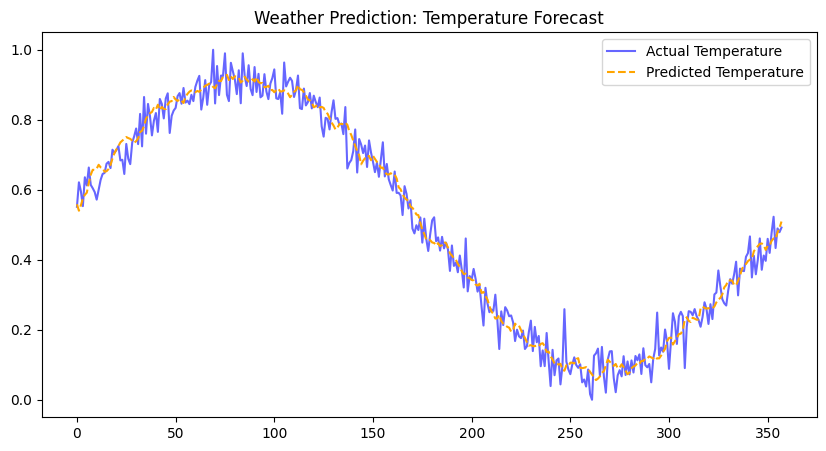

In [4]:
# Cell 4: Plotting Results
import matplotlib.pyplot as plt

predictions = model.predict(X)
plt.figure(figsize=(10, 5))
plt.plot(y, label='Actual Temperature', color='blue', alpha=0.6)
plt.plot(predictions, label='Predicted Temperature', color='orange', linestyle='--')
plt.title('Weather Prediction: Temperature Forecast')
plt.legend()
plt.show()